## 2.1. Разведочный анализ данных (EDA)

Загружу данные и посмотрю как они выглядят

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('retail_sales_mock_data.csv',
                 index_col = 'Date', parse_dates = True)
df.head()

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


Статистическое описание

Видно, что продажи ежемесячные

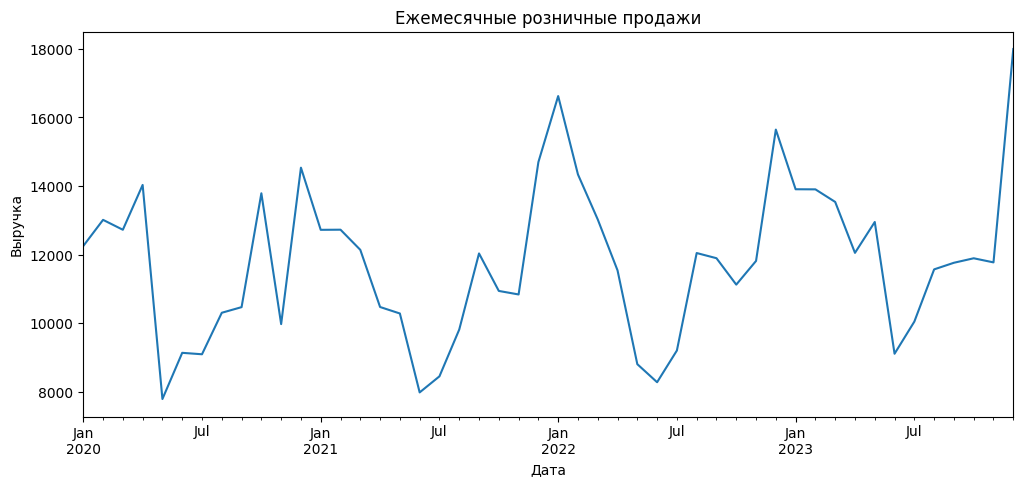

In [3]:
ax = df['SalesAmount'].plot(figsize = (12, 5), legend = None)
ax.set(title = 'Ежемесячные розничные продажи',
       xlabel = 'Дата',
       ylabel = 'Выручка');



Прослеживается сезонность, так как в январе каждого года видны характерные пики и спады в летнее время. Очень сильно бросается в глаза резкий рост выручки в декабре 2023 года, возможно были предновогодние акции или праздничная закупка перед новым годом. Выраженного тренда не наблюдается, так как выручка находится плюс минус на одном уровне

In [4]:
df['SalesAmount'].describe().round(2)

count       48.00
mean     11768.54
std       2257.54
min       7783.00
25%      10219.75
50%      11851.00
75%      13014.00
max      17996.00
Name: SalesAmount, dtype: float64

Из таблички видно, что датасет содержит 48 строк, я решила открыть его полностью и увидела, что данные ежемесячные за 4 года (гранулярность - месяц). Средняя выручка составляет 11 769 рублей. При этом разброс значений большой, так как стандартное отклонение 2258 рублей. Медиана составила 11 851 руб и близка к среднему, скорее всего не будет сильной асимметрии в распределении

межквартильный размах имеет формулу IQR = Q3 − Q1 = 13 014 - 10 219 = 2 794 руб, получила диапазон в котором находится средние 50% всех значений

Посчитаю границы выбросов:

Lower Bound = Q1 − 1.5×IQR = 10 220 − 1.5 × 2 794 = 6 029 руб

Upper Bound = Q3 + 1.5×IQR = 13 014 + 1.5 × 2 794 = 17 205 руб

Следовательно декабрь 2023 с выручкой приблизительно 18 000 руб является выбросом, так как выше верхней границы

In [5]:
print(f'Пропущенные значения: {df["SalesAmount"].isna().sum()}')


Пропущенные значения: 0


Пропущенных значений в данных нет, поэтому обработка данных не нужна

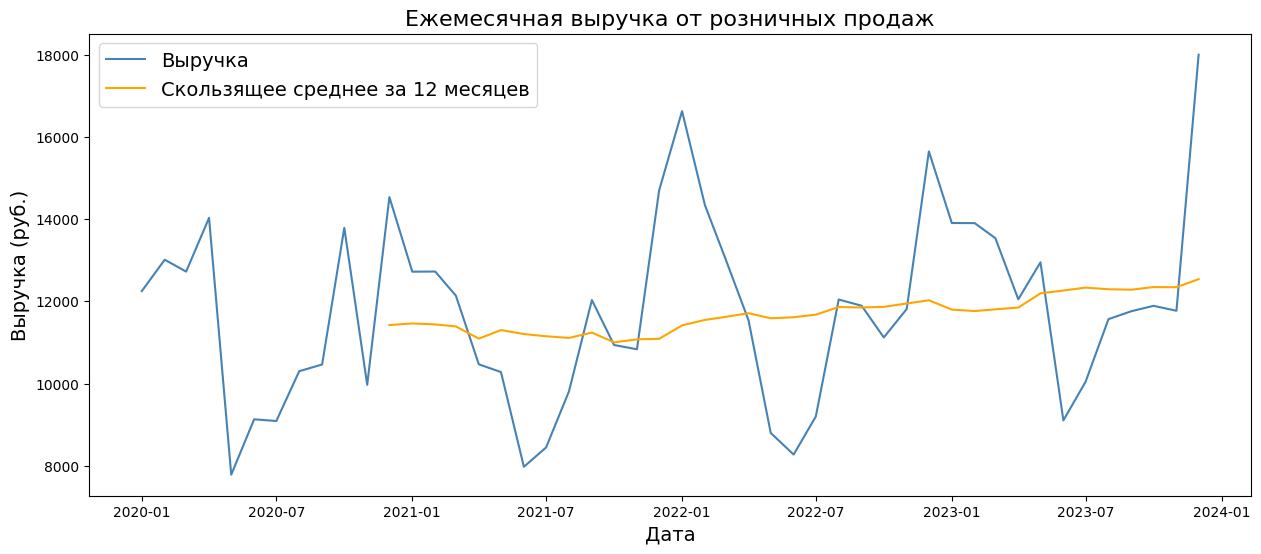

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(df['SalesAmount'], label='Выручка', color='steelblue')
plt.plot(df['SalesAmount'].rolling(window=12).mean(), label='Скользящее среднее за 12 месяцев', color='orange')

plt.legend(title='', loc='upper left', fontsize=14)

plt.xlabel('Дата', fontsize=14)
plt.ylabel('Выручка (руб.)', fontsize=14)
plt.title('Ежемесячная выручка от розничных продаж', fontsize=16)

plt.show()


Здесь уже тренд есть, но очень слабый. Средняя выручка выросла приблизительно с 11 000 до 12 500 рублей. На предыдущем графике тренд был не заметен, видимо из-за сильных сезонных колебаний

Можно сделать вывод, что ряд является нестационарным, так как есть явная сезонность и слабый восходящий тренд

Гистограмма

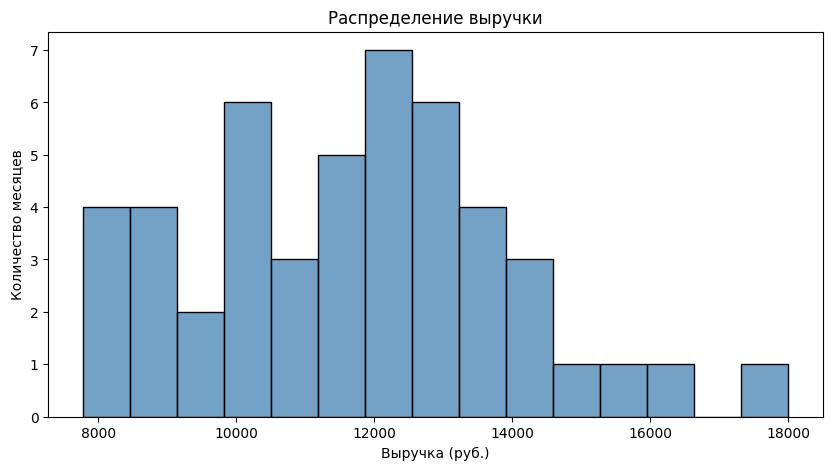

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df['SalesAmount'], bins=15, color='steelblue')
plt.title('Распределение выручки')
plt.xlabel('Выручка (руб.)')
plt.ylabel('Количество месяцев')
plt.show()

По гистограмме видно, что большинство месяцев выручка находилась в диапазоне от 10 000 до 13 000 руб. Один месяц с выручкой около 18 000 руб

Диаграмма размаха

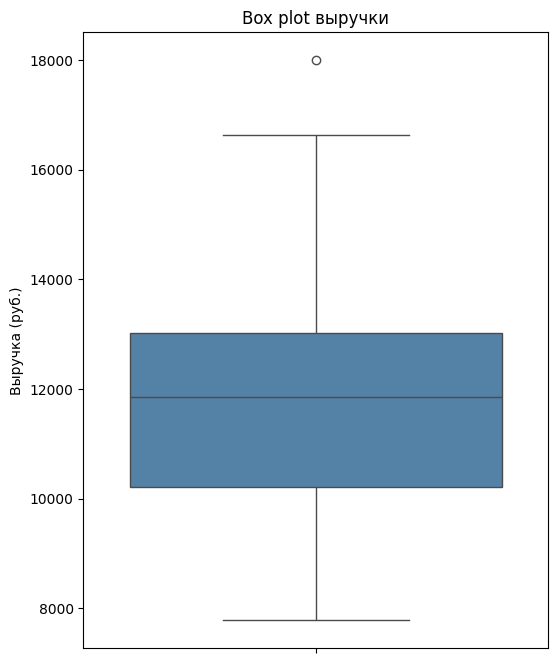

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 8))
sns.boxplot(y=df['SalesAmount'], color='steelblue')
plt.title('Box plot выручки')
plt.ylabel('Выручка (руб.)')
plt.show()

Синий прямоугольник охватывает средние 50% данных от 10 000 до 13 000. Линия внутри прямоугольника как раз медиана, в табличке чуть выше она как раз составила 11 850 рублей. Усы показывают нормальный диапазон значений. А кружок выше верхнего уса указывает на единичный выброс

 Анализ внешних факторов (Promotion и HolidayMonth)

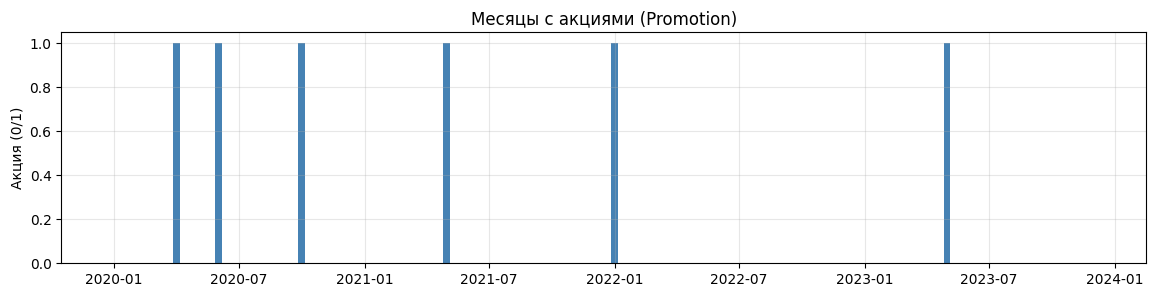

In [9]:
# Месяцы с акциями
plt.figure(figsize=(14, 3))
plt.bar(df.index, df['Promotion'], color='steelblue', width=10)
plt.title('Месяцы с акциями (Promotion)')
plt.ylabel('Акция (0/1)')
plt.grid(True, alpha=0.3)
plt.show()

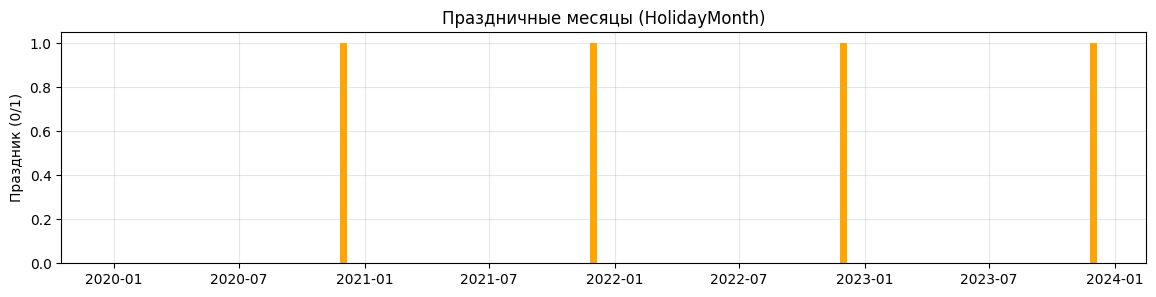

In [10]:
# Праздничные месяцы
plt.figure(figsize=(14, 3))
plt.bar(df.index, df['HolidayMonth'], color='orange', width=10)
plt.title('Праздничные месяцы (HolidayMonth)')
plt.ylabel('Праздник (0/1)')
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# Список месяцев, где была акция или праздник
print(df[df['Promotion'] == 1])
print(df[df['HolidayMonth'] == 1])

            SalesAmount  Promotion  HolidayMonth
Date                                            
2020-04-01        14030          1             0
2020-06-01         9131          1             0
2020-10-01        13786          1             0
2021-05-01        10279          1             0
2022-01-01        16623          1             0
2023-05-01        12949          1             0
            SalesAmount  Promotion  HolidayMonth
Date                                            
2020-12-01        14534          0             1
2021-12-01        14696          0             1
2022-12-01        15645          0             1
2023-12-01        17996          0             1


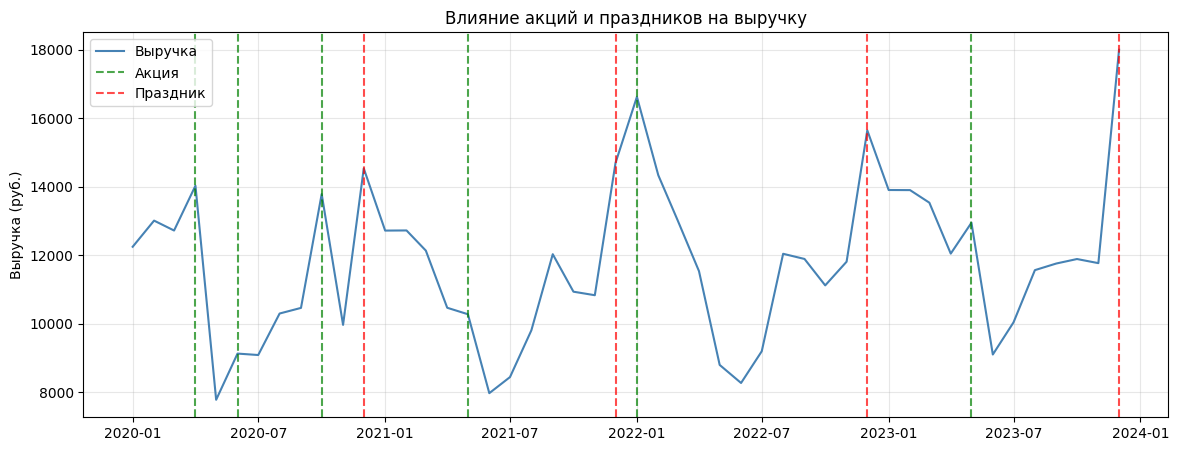

In [12]:
plt.figure(figsize=(14, 5))

# Выручка
plt.plot(df.index, df['SalesAmount'], color='steelblue', label='Выручка')

# Отмечаю акции вертикальными линиями
for date in df[df['Promotion'] == 1].index:
    plt.axvline(x=date, color='green', linestyle='--', alpha=0.7, label='Акция')

# Отмечаю праздники
for date in df[df['HolidayMonth'] == 1].index:
    plt.axvline(x=date, color='red', linestyle='--', alpha=0.7, label='Праздник')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.title('Влияние акций и праздников на выручку')
plt.ylabel('Выручка (руб.)')
plt.grid(True, alpha=0.3)
plt.show()


Вижу, что акции и праздники ни разу не пересекались. Праздничные месяцы совпадают со всеми декабрями, поэтому признак HolidayMonth дублирует по сути годовую сезонность и в эти месяцы выручка выше. Что касается акций, то они проводились в 6 месяцах из всех 48 и при этом в разное время года и нет четкой закономерности, но при этом акции сопровождают всплески продаж вне сезонного пика, это апрель и октябрь 2020, май 2023

Теплокарта (просто интересно)

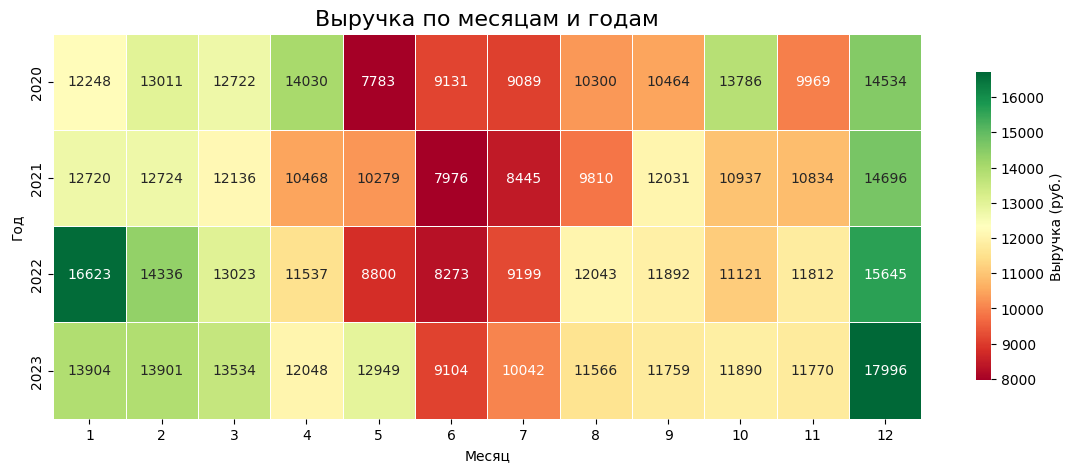

In [13]:
import seaborn as sns

# Создаю таблицу
df['Year'] = df.index.year
df['Month'] = df.index.month
pivot = df.pivot_table(values='SalesAmount', index='Year', columns='Month')

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap='RdYlGn', robust=True,
            fmt='.0f', annot=True, linewidths=.5,
            cbar_kws={'shrink': .8, 'label': 'Выручка (руб.)'})

plt.title('Выручка по месяцам и годам', fontsize=16)
plt.xlabel('Месяц')
plt.ylabel('Год')
plt.show()

На тепловой карте подтвержается сезонность уже в который раз). Каждый год летом (май-июль) выручка минимальная, а зимой (декабрь-январь) максимальная. Декабрь 2023 с выручкой 17 996 руб абсолютный рекорд за весь период. Январь 2022 также выделяется на фоне остальных январей

Автокорреляция

<Figure size 1500x400 with 0 Axes>

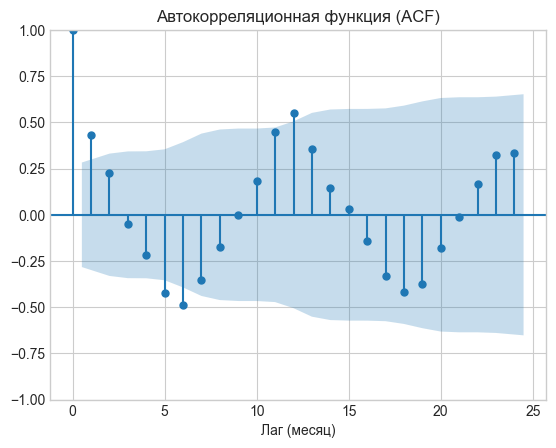

In [14]:
from statsmodels.graphics.tsaplots import plot_acf

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 4))
plot_acf(df['SalesAmount'].values.squeeze(), lags=24)
plt.title('Автокорреляционная функция (ACF)')
plt.xlabel('Лаг (месяц)')
plt.show()

Видны максимумы на лагах 6, 12, которые говорят о сезонности год. Для построения прогноза буду рассматривать признаки с лагами 1, 5, 6, 12. Также лаг 0 = 1, что говорит идеальная корреляция с самим собой. Отрицательные значения на лагах 6 и 7 указывают на то, что летние месяцы противоположны по характеру зимним, когда зимой пик, летом спад

<Figure size 1500x400 with 0 Axes>

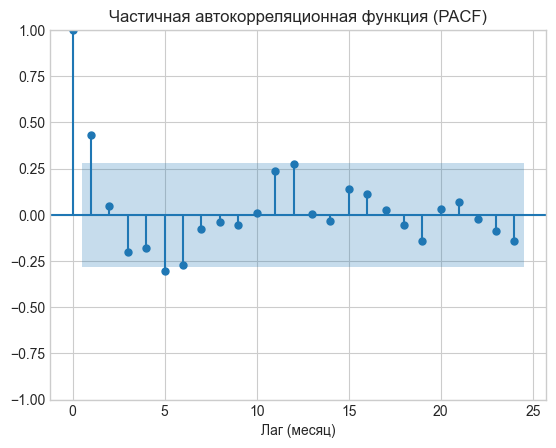

In [15]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 4))
plot_pacf(df['SalesAmount'].values.squeeze(), lags=24)
plt.title('Частичная автокорреляционная функция (PACF)')
plt.xlabel('Лаг (месяц)')
plt.show()

На графике значимый пик наблюдается только на лаге 1 значит, что текущее значение выручки напрямую зависит только от предыдущего месяца. Остальные лаги в основном находятся внутри голубой области и статистически незначим

Тест Дики-Фуллера

In [52]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['SalesAmount'], autolag='AIC')
print(f'p-value: {result[1]:.4f}')
print(f'Статистика теста: {result[0]:.4f}')

if result[1] < 0.05:
    print('Ряд стационарный')
else:
    print('Ряд нестационарный')

p-value: 0.0002
Статистика теста: -4.5142
Ряд стационарный


Тест Дики-Фуллера показал p-value = 0.0002, что меньше 0.05, значит ряд стационарный

1. seasonal_decompose

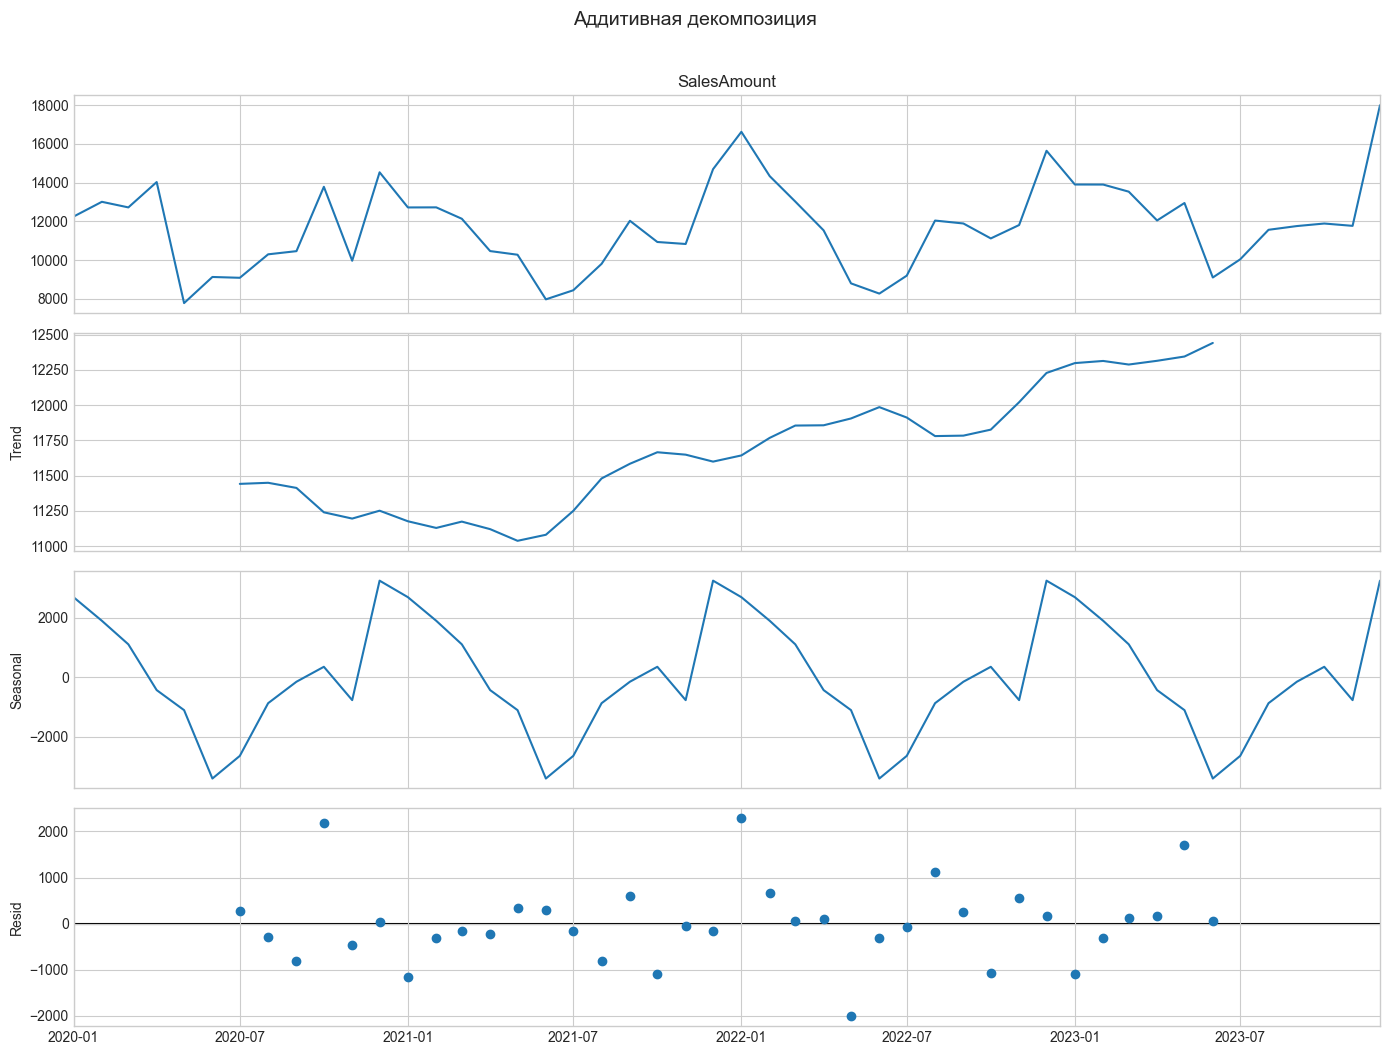

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose
from pylab import rcParams

df = pd.read_csv('retail_sales_mock_data.csv', 
                 index_col='Date', parse_dates=True)
df.sort_index(inplace=True)

rcParams['figure.figsize'] = 14, 10

decompose = seasonal_decompose(df['SalesAmount'], model='additive', period=12)
decompose.plot()
plt.suptitle('Аддитивная декомпозиция', y=1.05, fontsize=14)
plt.show()

Тренд имеет плавный рост выручки приблизительно с 11 000 до 12 500 за 4 года. Сезонность выражена, так как повторяется годовой паттерн (пики зимой в декабре и спад летом). Что касается остатков, то они случайные, разброс остатков одинаковый на всем периоде и без перекосов

Тренд не такой гладкий, а сезонность прерывистая, может попробовать мультипликативную модель запустить на тех же данных

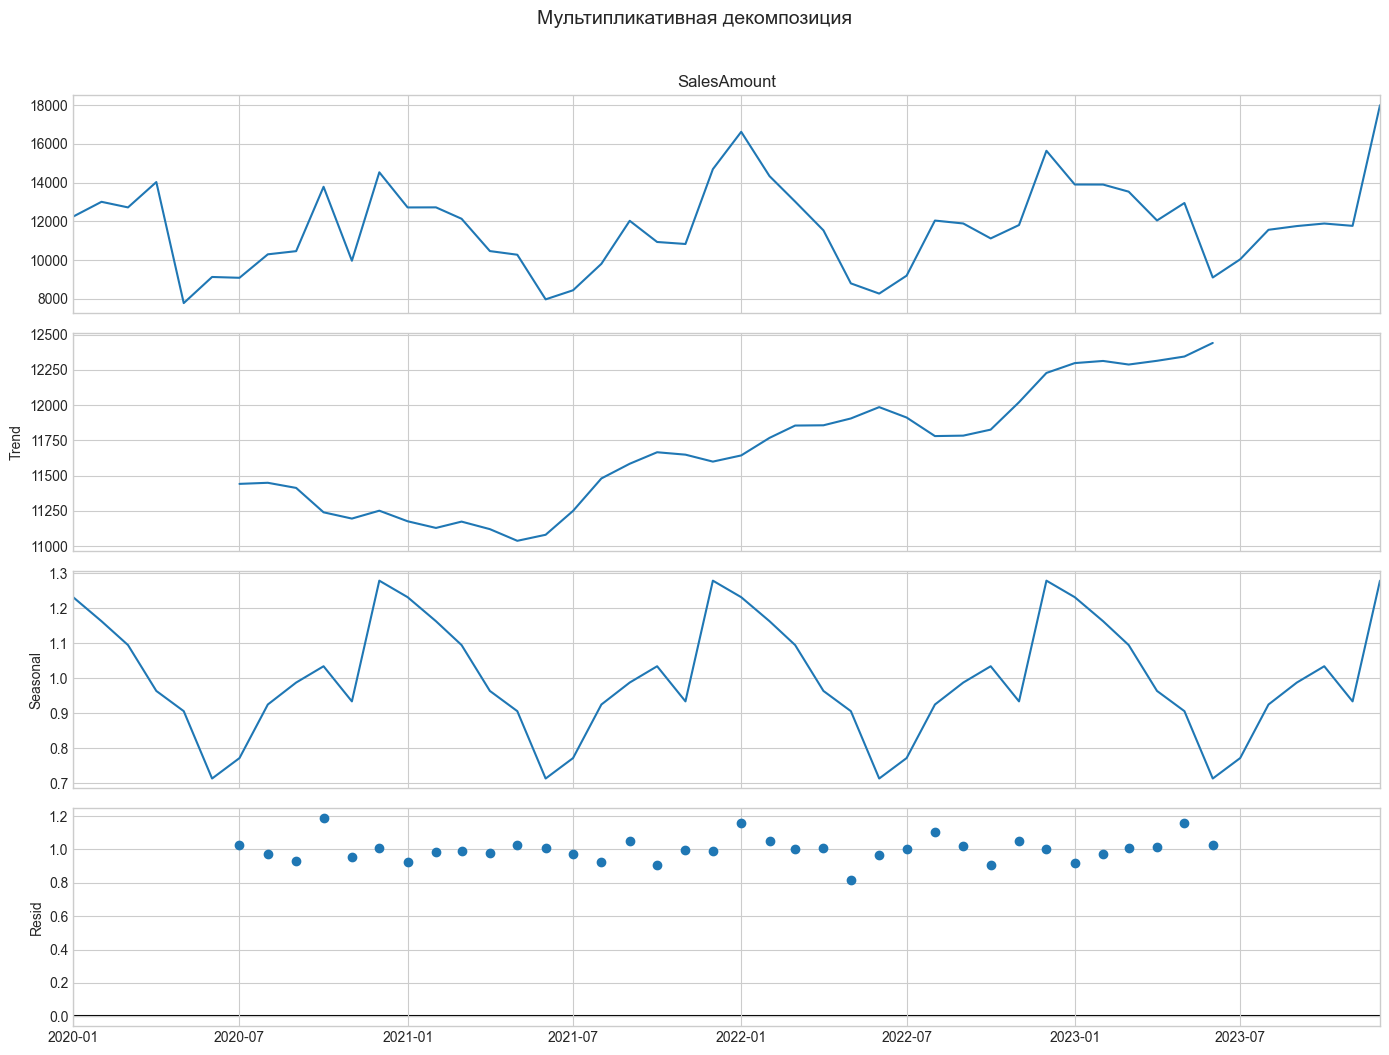

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose_mult = seasonal_decompose(df['SalesAmount'], model='multiplicative', period=12)
decompose_mult.plot()
plt.suptitle('Мультипликативная декомпозиция', y=1.05, fontsize=14)
plt.show()


У мультипликативной модели остатки только положительные, а это не хорошо

2. Спектральный анализ с применением быстрого преобразования Фурье (FFT)

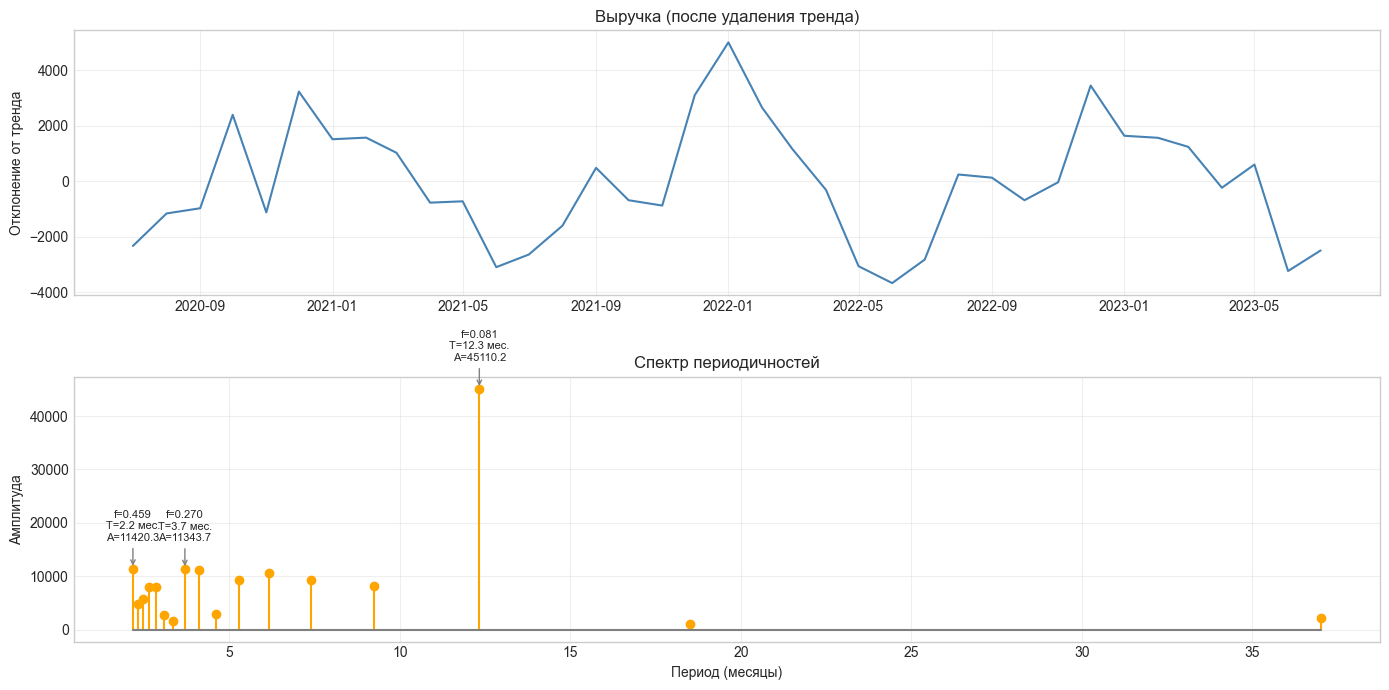

In [19]:
from scipy.fft import fft, fftfreq
import numpy as np

# Убираю тренд перед применением FFT с помощью скользящего среднего
sales_detrended = df['SalesAmount'] - df['SalesAmount'].rolling(12, center=True).mean()
sales_detrended = sales_detrended.dropna()

# Применяю быстрое преобразование Фурье
dt = 1  # шаг = 1 месяц
n = len(sales_detrended)
fft_vals = fft(sales_detrended.values)
freqs = fftfreq(n, dt)

# Беру только положительные частоты и перевожу в периоды
power = np.abs(fft_vals[:n//2])
freqs_pos = freqs[:n//2]
periods = 1 / freqs_pos[freqs_pos > 0]
power_pos = power[freqs_pos > 0]

fig, axs = plt.subplots(2, 1, figsize=(14, 7))

# Показываю ряд после удаления тренда
axs[0].plot(sales_detrended.index, sales_detrended.values, color='steelblue')
axs[0].set_title('Выручка (после удаления тренда)')
axs[0].set_ylabel('Отклонение от тренда')
axs[0].grid(True, alpha=0.3)

# Строю спектр
mask = (periods >= 2) & (periods <= 48)
axs[1].stem(periods[mask], power_pos[mask], linefmt='orange', markerfmt='o', basefmt='gray')
axs[1].set_xlabel('Период (месяцы)')
axs[1].set_ylabel('Амплитуда')
axs[1].set_title('Спектр периодичностей')
axs[1].grid(True, alpha=0.3)

# Подписываю самые сильные пики на спектре
for f in freqs[np.argsort(power)[-3:][::-1]]:
    if f > 0.01:
        period = 1/f
        amp = power[np.argmin(np.abs(freqs - f))]
        label = f'f={f:.3f}\nT={period:.1f} мес.\nA={amp:.1f}'
        axs[1].annotate(label,
                       xy=(period, amp), xytext=(0, 20), textcoords='offset points',
                       fontsize=8, ha='center',
                       arrowprops=dict(arrowstyle='->', color='gray'))


plt.tight_layout()
plt.show()


На спектре сильно выделяется один пик с периодом около 12 месяцев. Он примерно в 4 раза выше всех остальных (его амплитуда 45 110), то есть главная периодичность в данных годовая. Остальные небольшие пики (2–9 месяцев) это шум и дополнительные волны

3. Вейвлет-анализ (например, с использованием вейвлета Морле или Добеши)

C:\Users\Алина\AppData\Local\Temp\ipykernel_15092\1677244103.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


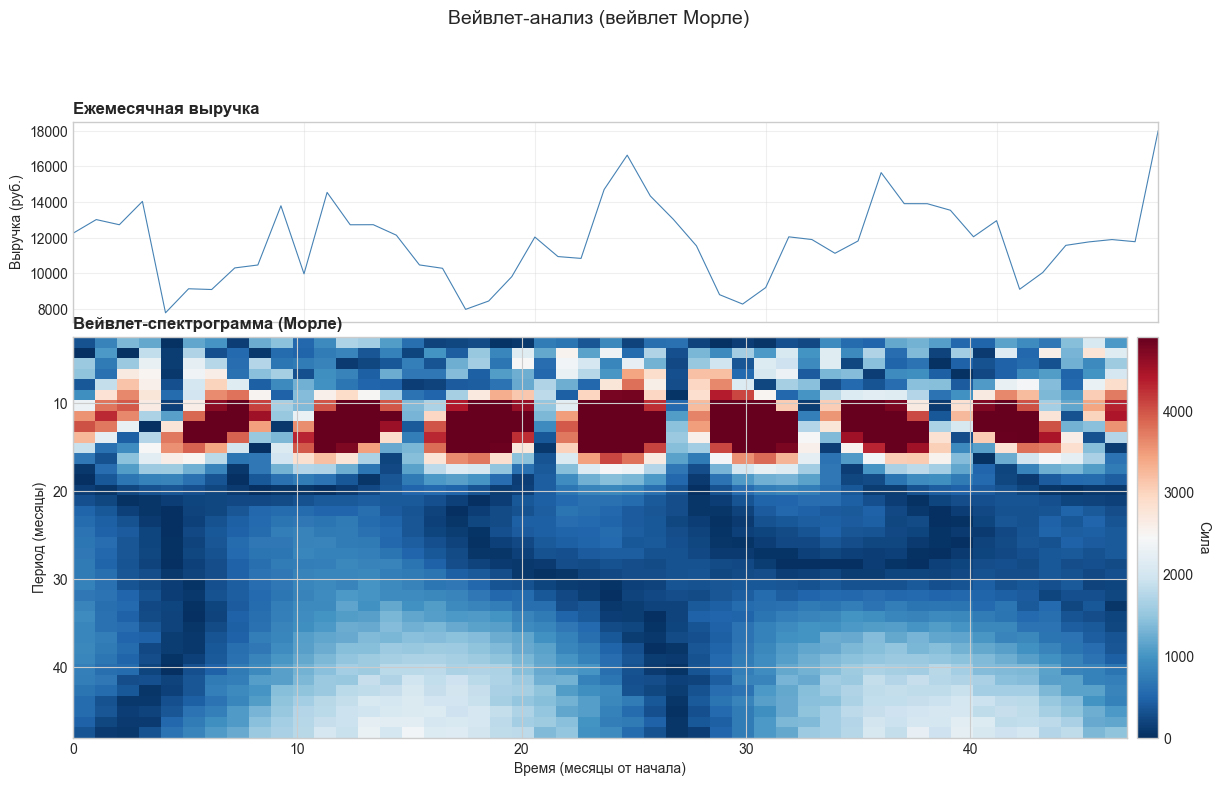

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.style.use('seaborn-v0_8-whitegrid')

# Подготовка данных
signal = df['SalesAmount'].values
signal_centered = signal - signal.mean() 
t = np.arange(len(signal))  # индексы месяцев
sampling_period = 1

# Вейвлет-преобразование Морле
wavelet = 'morl'
scales = np.arange(1, 48)
coefficients, frequencies = pywt.cwt(signal_centered, scales, wavelet, sampling_period=sampling_period)   

# Подготовка спектрограммы
mask = frequencies > 0
periods = 1 / frequencies[mask]
coefficients_abs = np.abs(coefficients[mask, :])
period_mask = (periods >= 2) & (periods <= 48)
periods_plot = periods[period_mask]
coefficients_plot = coefficients_abs[period_mask, :]

# Визуализация
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                        gridspec_kw={'height_ratios': [1, 2], 'hspace': 0.05})

# Исходный сигнал
axs[0].plot(t, signal, color='steelblue', linewidth=0.8)
axs[0].set_title('Ежемесячная выручка', fontweight='bold', loc='left')
axs[0].set_ylabel('Выручка (руб.)')
axs[0].grid(True, alpha=0.3)

# Спектрограмма
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="2%", pad=0.1)

im = axs[1].imshow(coefficients_plot,
                   extent=[t.min(), t.max(), periods_plot.max(), periods_plot.min()],
                   aspect='auto', cmap='RdBu_r',
                   vmin=0, vmax=np.percentile(coefficients_plot, 95))
axs[1].set_title('Вейвлет-спектрограмма (Морле)', fontweight='bold', loc='left')
axs[1].set_ylabel('Период (месяцы)')
axs[1].set_xlabel('Время (месяцы от начала)')

cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Сила', rotation=270, labelpad=12)

plt.suptitle('Вейвлет-анализ (вейвлет Морле)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


На спектрограмме я вижу яркие красно-оранжевые пятна в верхней части графика на периодах около 8–15 месяцев. Полоса находится на уровне около 12 месяцев по вертикальной оси показывает годовую сезонность, она есть на протяжении всех 4 лет. По горизонтали пятна повторяются примерно каждые 6 месяцев, потому что вейвлет Морле реагирует отдельно на пики (декабрь) и провалы (июнь) сезонной волны. Пятна выглядят одинаковыми. Что касается нижней части, то периоды 20–48 месяцев есть слабые белёсые пятна это слабый сигнал на длинных периодах

Сравнение результатов методов, их применимости и преимущества и недоастатки

Я применила три метода декомпозиции чтобы лучше понять структуру ряда.

Начала с классической аддитивной декомпозиции через seasonal_decompose. Этот метод оказался самым простым и наглядным, он разбил ряд на тренд, сезонность и остатки. Я увидела что тренд постепенно растёт примерно с 11 000 до 12 500 руб. за 4 года, сезонность чётко повторяется каждый год с пиками зимой и спадами летом, а остатки небольшие и разброс у них одинаковый на всём периоде. Также попробовала мультипликативную модель, но она дала хуже результат, остатки были смещены выше 1, поэтому аддитивная подошла лучше. Главный минус этого метода в том что он не может показать меняется ли сезонность со временем.

Второй метод это спектральный анализ FFT. Перед применением я убрала тренд через скользящее среднее. FFT нашёл один главный пик на периоде 12 месяцев с амплитудой 45 110, что в разы больше всех остальных пиков. Это математически подтвердило годовую сезонность. Мелкие пики в начале спектра на периодах 2-5 месяцев оказались не реальными циклами, а гармониками основного пика. Минус этого метода в том что он не показывает когда именно в ряду проявляется тот или иной цикл.

Третий метод это вейвлет-анализ с вейвлетом Морле. Он единственный показал как сезонность ведёт себя во времени. На спектрограмме красные пятна одинаковые на протяжении всех 4 лет, значит сезонность не усиливается и не ослабевает. Слабые пятна в нижней части скорее всего отражают слабый тренд. Из минусов этот метод сложнее всего читать и интерпретировать.

Все три метода показали одно и то же, в данных есть устойчивая годовая сезонность с периодом 12 месяцев

## 2.2. Построение прогнозных моделей

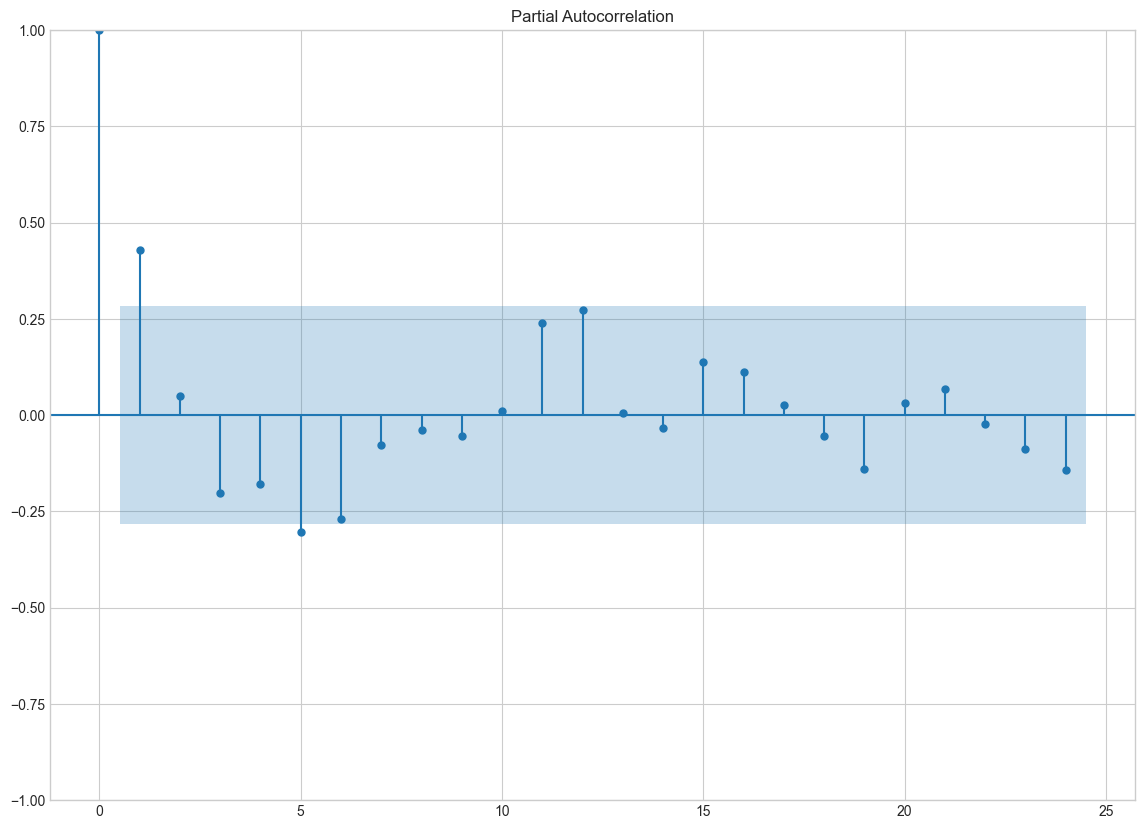

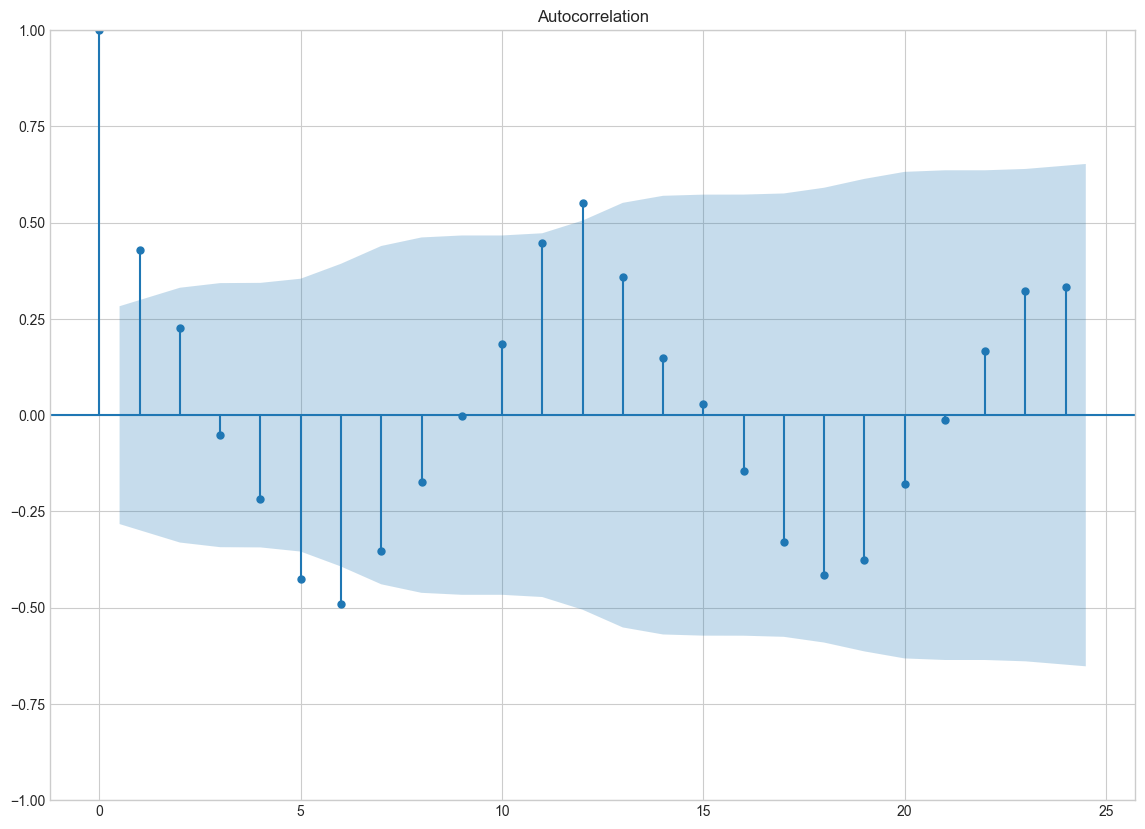

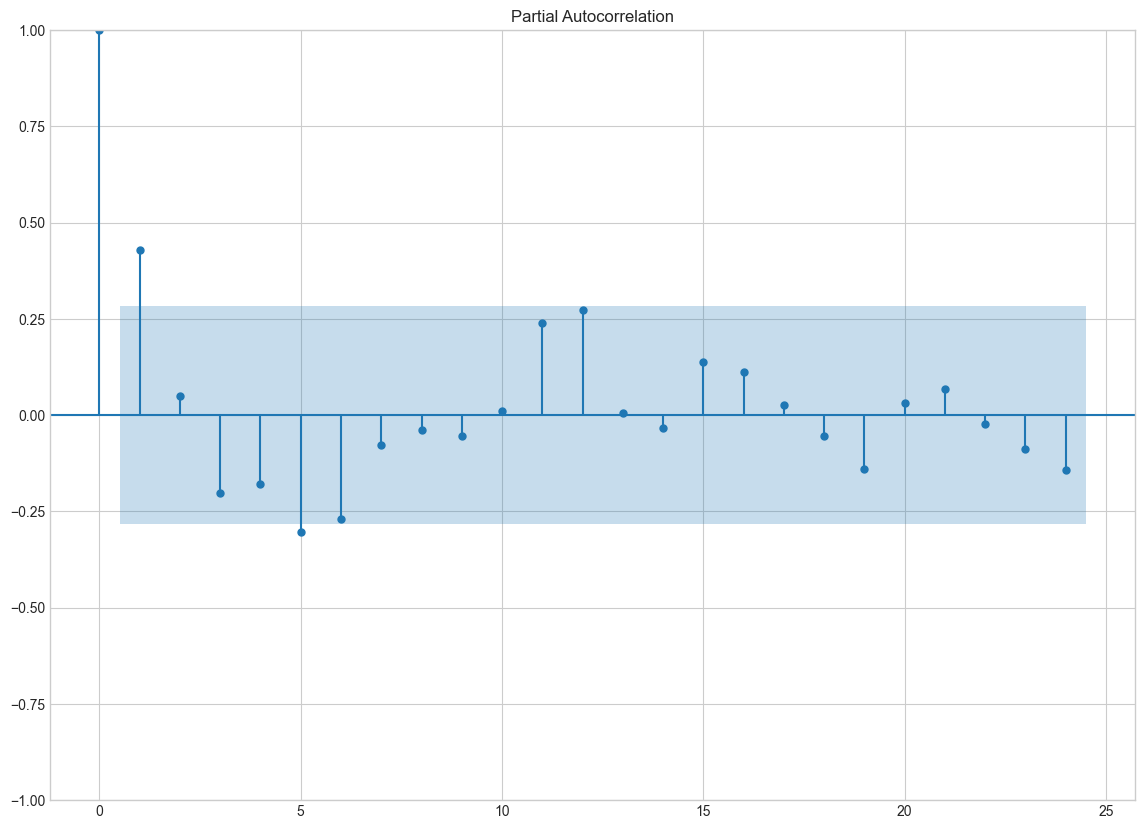

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['SalesAmount'].values.squeeze(), lags=24)
plot_pacf(df['SalesAmount'].values.squeeze(), lags=24)

Делю данные на обучающую и тестовую выборку. Первые 36 месяцев (это получается 2020-2022 года), а оставшиеся 12 месяцев (2023 год) отправлю на тест

In [22]:
train = df['SalesAmount'][:-12]
test = df['SalesAmount'][-12:]
print(f'Обучающая выборка: {len(train)} месяцев')
print(f'Тестовая выборка: {len(test)} месяцев')

Обучающая выборка: 36 месяцев
Тестовая выборка: 12 месяцев


Пытаюсь вручную подобрать параметры для ARIMA. Первый параметр(p) - авторегрессия, для этого я повторно вывела графики чуть выше. По графику видно, что в прогноз пойдут лаги: 1, 5, 6, 12 (высоки пики у 6 и 12 лага). Второй параметр (d) отвечает за интегрирование, так как тест Дики Фуллера показал что ряд стационарен p-value = 0.0002 < 0.05, следовательно ряд является стационарным. Третий параметр (q) - модель скользящего среднего, учитывает ошибки прошлых прогнозов

С d всё понятно, дифференцировать не надо, поэтому он равен 0

p и q подбирается с помощью графиков ACF и PACF, где график ACF помогает определить параметр q (для MA), а график PACF помогает определить параметр p (для AR)

На PACF ищу точку, где столбик впервые обрывается за пределами синей области (незначимой). Это лаг будет кандидатом для p. На ACF ищу аналогично для q

У меня получилось: 

p = 5

q = 6

12 лаг для q я не стала брать, так как датасет и так маленький и 12 было бы жестко

In [60]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train, order=(5, 0, 6))
result_arima = model_arima.fit()

print(result_arima.summary())

                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   36
Model:                 ARIMA(5, 0, 6)   Log Likelihood                -334.952
Date:                Tue, 06 Oct 2026   AIC                            695.905
Time:                        22:43:03   BIC                            716.491
Sample:                    01-01-2020   HQIC                           703.090
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.151e+04     37.317    308.489      0.000    1.14e+04    1.16e+04
ar.L1          0.7434      0.078      9.498      0.000       0.590       0.897
ar.L2         -0.2684      0.060     -4.494      0.0

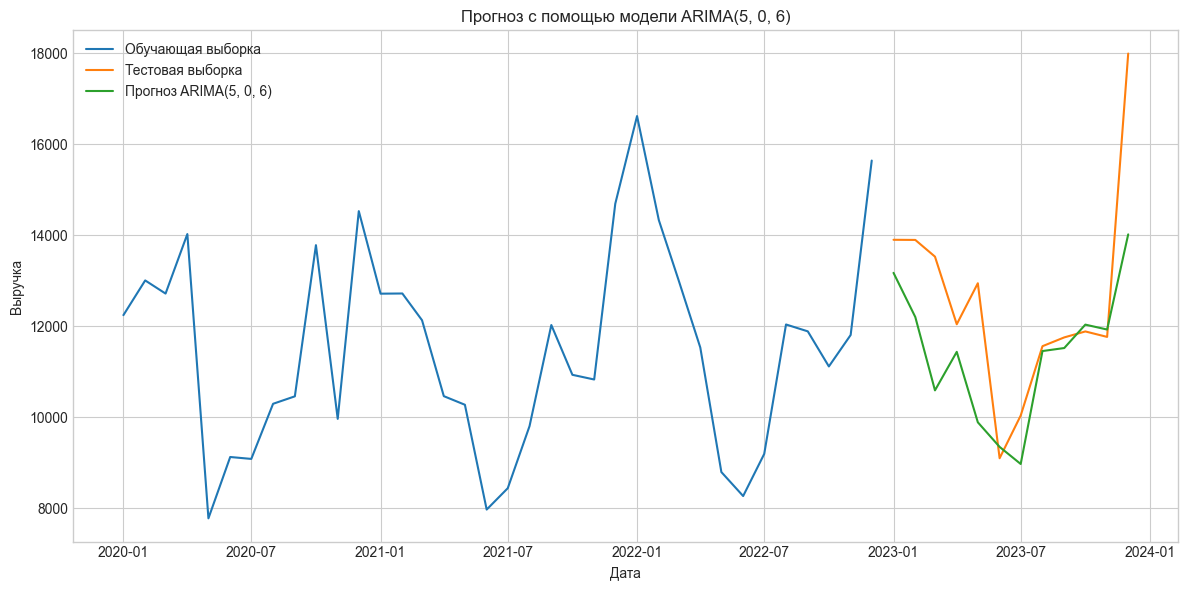

In [61]:
# Строю прогноз на тестовый период (12 месяцев)
forecast_arima = result_arima.predict(start=len(train), end=len(train) + len(test) - 1)

plt.figure(figsize=(12, 6))
sns.lineplot(data=train, label='Обучающая выборка')
sns.lineplot(data=test, label='Тестовая выборка')
sns.lineplot(data=forecast_arima, label='Прогноз ARIMA(5, 0, 6)')
plt.title('Прогноз с помощью модели ARIMA(5, 0, 6)')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.legend()
plt.tight_layout()
plt.show()

Зеленая линия, отвечающая за прогноз хорошо учитывает особенности, если смотреть на тестовую линию. Также учитывается сезонность, так как виден спад в июле 2023 года, а в конце года предсказал подъем как и должно быть, хотя декабрьский пик немного недооценила

Автоматический подбор параметров

In [62]:
from pmdarima import auto_arima

model_auto = auto_arima(
    train,
    start_p=0, max_p=5,
    start_q=0, max_q=6,
    d=None,
    seasonal=False,
    trace=True,
    stepwise=True
)

print(f"\nОптимальный порядок: {model_auto.order}")
print(f"AIC = {model_auto.aic():.3f}")


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=778.739, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=664.123, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=744.544, Time=0.05 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=664.726, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=665.549, Time=0.10 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=653.040, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=660.355, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=655.042, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=655.105, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=655.621, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=656.320, Time=0.09 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.456 seconds

Оптимальный порядок: (1, 0, 0)
AIC = 653.040


Проверка с предложенным вариантом автоподбора

In [63]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train, order=(1, 0, 0), trend='c')
result_arima = model_arima.fit()

print(result_arima.summary())

                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   36
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -323.535
Date:                Tue, 06 Oct 2026   AIC                            653.070
Time:                        22:43:50   BIC                            657.821
Sample:                    01-01-2020   HQIC                           654.728
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.151e+04    669.394     17.197      0.000    1.02e+04    1.28e+04
ar.L1          0.4941      0.190      2.601      0.009       0.122       0.866
sigma2       3.81e+06   9.21e+05      4.136      0.0

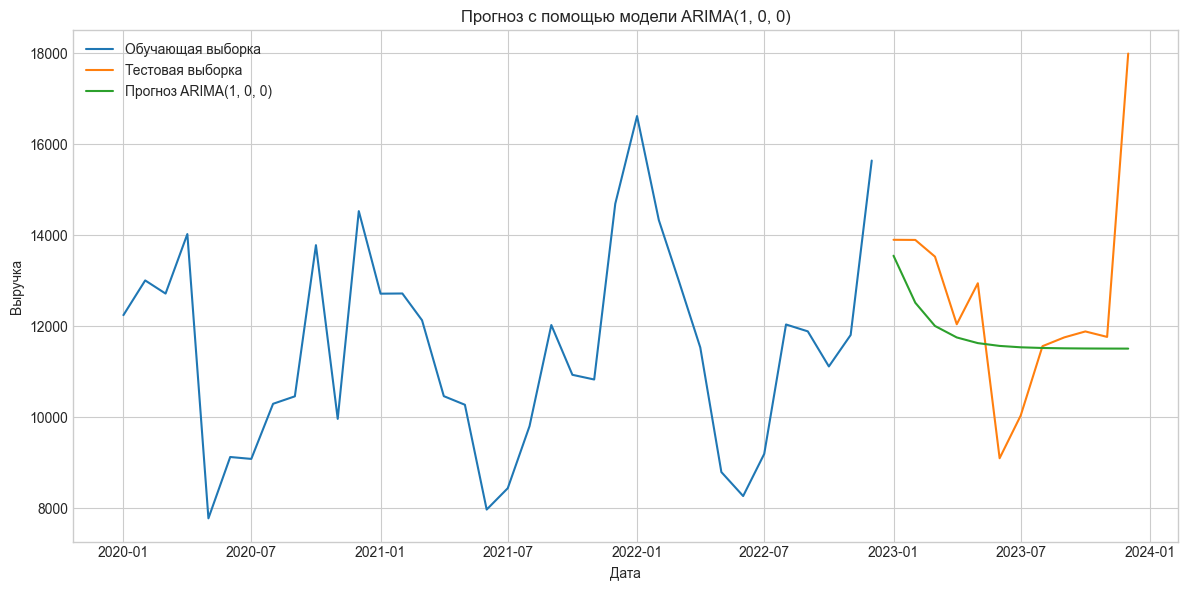

In [64]:
forecast_arima = result_arima.predict(start=len(train), end=len(train) + len(test) - 1)

plt.figure(figsize=(12, 6))
sns.lineplot(data=train, label='Обучающая выборка')
sns.lineplot(data=test, label='Тестовая выборка')
sns.lineplot(data=forecast_arima, label='Прогноз ARIMA(1, 0, 0)')
plt.title('Прогноз с помощью модели ARIMA(1, 0, 0)')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.legend()
plt.tight_layout()
plt.show()

Сравню результаты ручного подбора и автоподбора: в данном случае автоподбор сработал плохо. Зеленая линия ARIMA(1,0,0) просто уходит в плавный спуск без колебаний и не отражает природу данных. А вот у ARIMA(5,0,6) наоборот, описывает природу данных, так как спускается с реальными данными летом, поднимается к осени и почти догоняет до значения в декабре, здесь прогноз более реален. Но из-за сложности модели пришлось пожертвовать немного AIC (с 653 до 695)

ARIMA не учитывает сезонность, поэтому воспользуюсь SARIMAX, которая добавляет сезонные параметры (P, D, Q, s), где s-сезонность, и так как сезонность у меня по eda годовая, то s=12. Также в данных у меня есть праздники и акции, которые относятся к экзогенным данным, которые не случаются часто, т.е внешние факторы, которые так или иначе будут влиять на выручку

Экзогенные данные

разобью экзогенные данные тоже на обучающую и тестовую выборки

In [28]:
exog_train = df[['Promotion', 'HolidayMonth']][:-12]
exog_test  = df[['Promotion', 'HolidayMonth']][-12:]

print('Экзогенные переменные (обучение):')
print(exog_train.tail())
print(f'\nРазмер: {exog_train.shape}')

print('\nЭкзогенные переменные (тест):')
print(exog_test)
print(f'\nРазмер: {exog_test.shape}')

Экзогенные переменные (обучение):
            Promotion  HolidayMonth
Date                               
2022-08-01          0             0
2022-09-01          0             0
2022-10-01          0             0
2022-11-01          0             0
2022-12-01          0             1

Размер: (36, 2)

Экзогенные переменные (тест):
            Promotion  HolidayMonth
Date                               
2023-01-01          0             0
2023-02-01          0             0
2023-03-01          0             0
2023-04-01          0             0
2023-05-01          1             0
2023-06-01          0             0
2023-07-01          0             0
2023-08-01          0             0
2023-09-01          0             0
2023-10-01          0             0
2023-11-01          0             0
2023-12-01          0             1

Размер: (12, 2)


In [29]:
print(df[['Promotion', 'HolidayMonth']].sum())

Promotion       6
HolidayMonth    4
dtype: int64


In [65]:
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Перебираю комбинации несезонных и сезонных параметров
nonseasonal_orders = [(0,0,0), (1,0,0), (0,0,1), (1,0,1), (5,0,6)]
seasonal_orders    = [(1,1,0,12), (2,1,0,12), (1,1,1,12), (0,1,1,12)]

aic_values = []
bic_values = []
params = []

for order in nonseasonal_orders:
    for s_order in seasonal_orders:
        model = SARIMAX(train, exog=exog_train, order=order, seasonal_order=s_order).fit(disp=False)
        aic_values.append(model.aic)
        bic_values.append(model.bic)
        params.append((order, s_order))
        print(f'SARIMAX{order}{s_order} — AIC: {model.aic:.2f}, BIC: {model.bic:.2f}')

best_aic = params[np.argmin(aic_values)]
best_bic = params[np.argmin(bic_values)]
print(f'\nЛучшая модель по AIC: SARIMAX{best_aic[0]}{best_aic[1]}')
print(f'Лучшая модель по BIC: SARIMAX{best_bic[0]}{best_bic[1]}')

SARIMAX(0, 0, 0)(1, 1, 0, 12) — AIC: 406.99, BIC: 411.70
SARIMAX(0, 0, 0)(2, 1, 0, 12) — AIC: 394.00, BIC: 399.89
SARIMAX(0, 0, 0)(1, 1, 1, 12) — AIC: 402.48, BIC: 408.37
SARIMAX(0, 0, 0)(0, 1, 1, 12) — AIC: 406.29, BIC: 411.00
SARIMAX(1, 0, 0)(1, 1, 0, 12) — AIC: 406.20, BIC: 412.09
SARIMAX(1, 0, 0)(2, 1, 0, 12) — AIC: 394.61, BIC: 401.67
SARIMAX(1, 0, 0)(1, 1, 1, 12) — AIC: 401.69, BIC: 408.76
SARIMAX(1, 0, 0)(0, 1, 1, 12) — AIC: 406.28, BIC: 412.17
SARIMAX(0, 0, 1)(1, 1, 0, 12) — AIC: 406.24, BIC: 412.13
SARIMAX(0, 0, 1)(2, 1, 0, 12) — AIC: 394.58, BIC: 401.65
SARIMAX(0, 0, 1)(1, 1, 1, 12) — AIC: 401.99, BIC: 409.06
SARIMAX(0, 0, 1)(0, 1, 1, 12) — AIC: 406.29, BIC: 412.18
SARIMAX(1, 0, 1)(1, 1, 0, 12) — AIC: 408.19, BIC: 415.26
SARIMAX(1, 0, 1)(2, 1, 0, 12) — AIC: 394.28, BIC: 402.53
SARIMAX(1, 0, 1)(1, 1, 1, 12) — AIC: 397.51, BIC: 405.75
SARIMAX(1, 0, 1)(0, 1, 1, 12) — AIC: 408.32, BIC: 415.39
SARIMAX(5, 0, 6)(1, 1, 0, 12) — AIC: 406.92, BIC: 424.59
SARIMAX(5, 0, 6)(2, 1, 0, 12) —

In [71]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarimax = SARIMAX(
    train,
    exog=exog_train,
    order=(5, 0, 6),
    seasonal_order=(2, 1, 0, 12)
)
result_sarimax = model_sarimax.fit(disp=False)

print(result_sarimax.summary())

                                      SARIMAX Results                                      
Dep. Variable:                         SalesAmount   No. Observations:                   36
Model:             SARIMAX(5, 0, 6)x(2, 1, [], 12)   Log Likelihood                -187.875
Date:                             Tue, 06 Oct 2026   AIC                            407.750
Time:                                     22:59:33   BIC                            426.599
Sample:                                 01-01-2020   HQIC                           412.751
                                      - 12-01-2022                                         
Covariance Type:                               opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Promotion     2574.0008   1108.340      2.322      0.020     401.693    4746.308
HolidayMonth  8.447e-

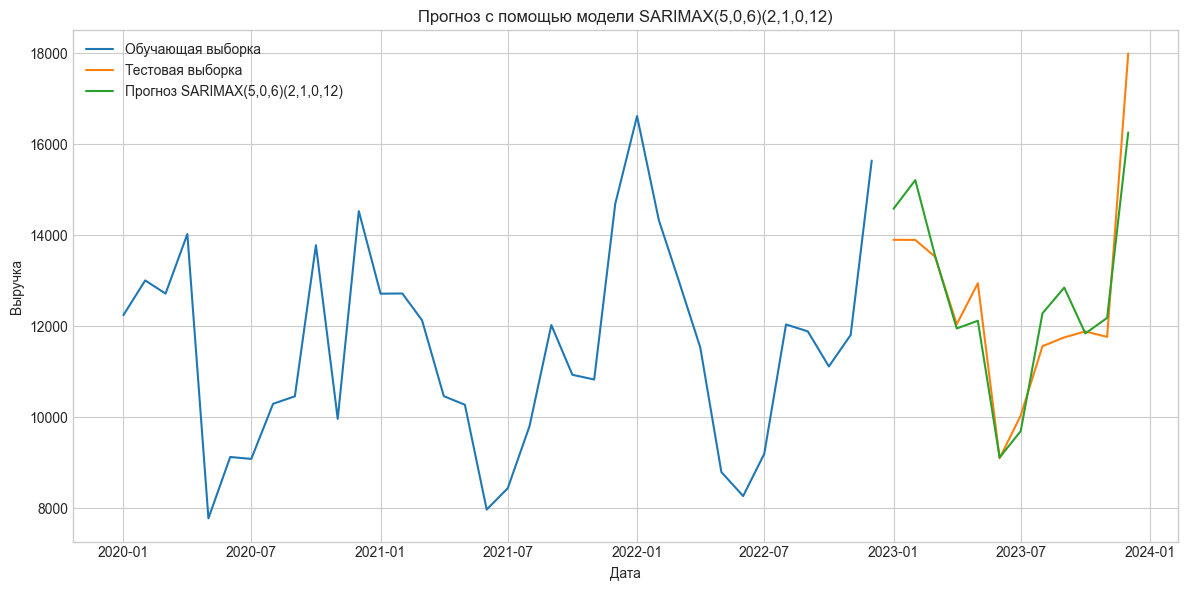

In [72]:
forecast_sarimax = result_sarimax.predict(
    start=len(train),
    end=len(train) + len(test) - 1,
    exog=exog_test
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=train, label='Обучающая выборка')
sns.lineplot(data=test, label='Тестовая выборка')
sns.lineplot(data=forecast_sarimax, label='Прогноз SARIMAX(5,0,6)(2,1,0,12)')
plt.title('Прогноз с помощью модели SARIMAX(5,0,6)(2,1,0,12)')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.legend()
plt.tight_layout()
plt.show()


Зелёная линия следует за реальными значениями и улавливает общую форму сезонных колебаний и много где совпадает с тестовой линией. В начале тестового периода (январь 2023) модель правильно предсказала пик около 14000. Затем спад в середине года тоже показан верно. К концу 2023 года модель предсказала подъём, хотя реальный декабрьский пик около 18000 она немного недооценила и остановилась примерно на 15500. Думаю это связано с тем что в декабре был праздничный месяц и модель не до конца учла насколько сильно это влияет на выручку при таком маленьком датасете

Хочу глянуть что предложит автоподбор

In [74]:
import warnings
warnings.filterwarnings('ignore')
from pmdarima import auto_arima

model_auto_sarima = auto_arima(
    train,
    exogenous=exog_train,
    start_p=0, max_p=5,
    start_q=0, max_q=6,
    seasonal=True,
    m=12,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print(f"\nЛучшие параметры: {model_auto_sarima.order}{model_auto_sarima.seasonal_order}")
print(f"AIC = {model_auto_sarima.aic():.3f}")


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.39 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=425.761, Time=0.01 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=426.130, Time=0.07 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=425.628, Time=0.07 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=424.616, Time=0.01 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=424.339, Time=0.05 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=423.373, Time=0.26 sec
 ARIMA(0,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=0.66 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=426.322, Time=0.15 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=425.423, Time=0.13 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=inf, Time=0.56 sec
 ARIMA(0,0,0)(2,1,0)[12]             : AIC=422.538, Time=0.07 sec
 ARIMA(0,0,0)(1,1,0)[12]             : AIC=425.114, Time=0.03 sec
 ARIMA(0,0,0)(2,1,1)[12]             : AIC=424.332, Time=0.11 sec
 ARIMA(0,0,0)(1,1,1)[12]             : AIC=in

Переобучу саримакс с найденными параметрами

In [34]:
model_sarimax = SARIMAX(
    train,
    exog=exog_train,
    order=(0, 0, 0),
    seasonal_order=(2, 1, 0, 12)
)
result_sarimax = model_sarimax.fit(disp=False)

print(result_sarimax.summary())


                                SARIMAX Results                                 
Dep. Variable:              SalesAmount   No. Observations:                   36
Model:             SARIMAX(2, 1, 0, 12)   Log Likelihood                -192.001
Date:                  Tue, 06 Oct 2026   AIC                            394.001
Time:                          21:42:35   BIC                            399.891
Sample:                      01-01-2020   HQIC                           395.564
                           - 12-01-2022                                         
Covariance Type:                    opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Promotion     2574.0000    446.419      5.766      0.000    1699.034    3448.966
HolidayMonth  3.165e-07    2.9e+04   1.09e-11      1.000   -5.68e+04    5.68e+04
ar.S.L12      2.638e-05     

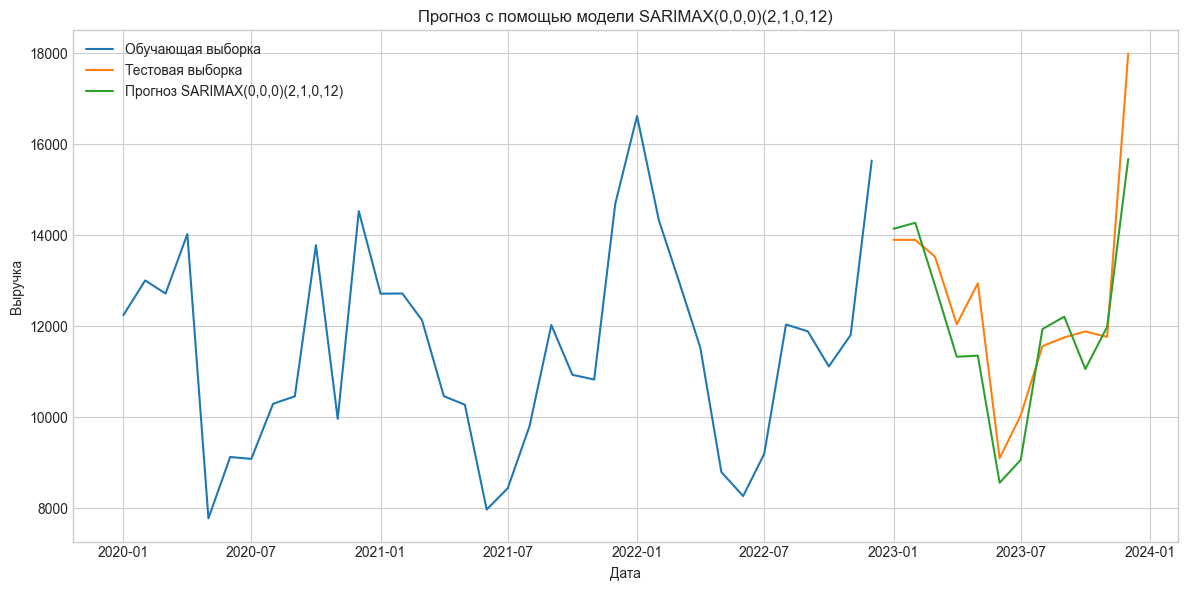

In [35]:
forecast_sarimax = result_sarimax.predict(
    start=len(train),
    end=len(train) + len(test) - 1,
    exog=exog_test
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=train, label='Обучающая выборка')
sns.lineplot(data=test, label='Тестовая выборка')
sns.lineplot(data=forecast_sarimax, label='Прогноз SARIMAX(0,0,0)(2,1,0,12)')
plt.title('Прогноз с помощью модели SARIMAX(0,0,0)(2,1,0,12)')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.legend()
plt.tight_layout()
plt.show()


Плюс минус тоже самое, если сравнивать с предыдущем графиком. Единственное, информационный критерий AIC снизился с 655 до 422

Интересно глянуть график с доверительным интервалом

Я дообучила финальную модель SARIMAX на всех доступных данных и построила прогноз на 12 месяцев вперёд. Для будущего периода экзогенные переменные я задала нулями, так как заранее неизвестно когда будут акции и праздники

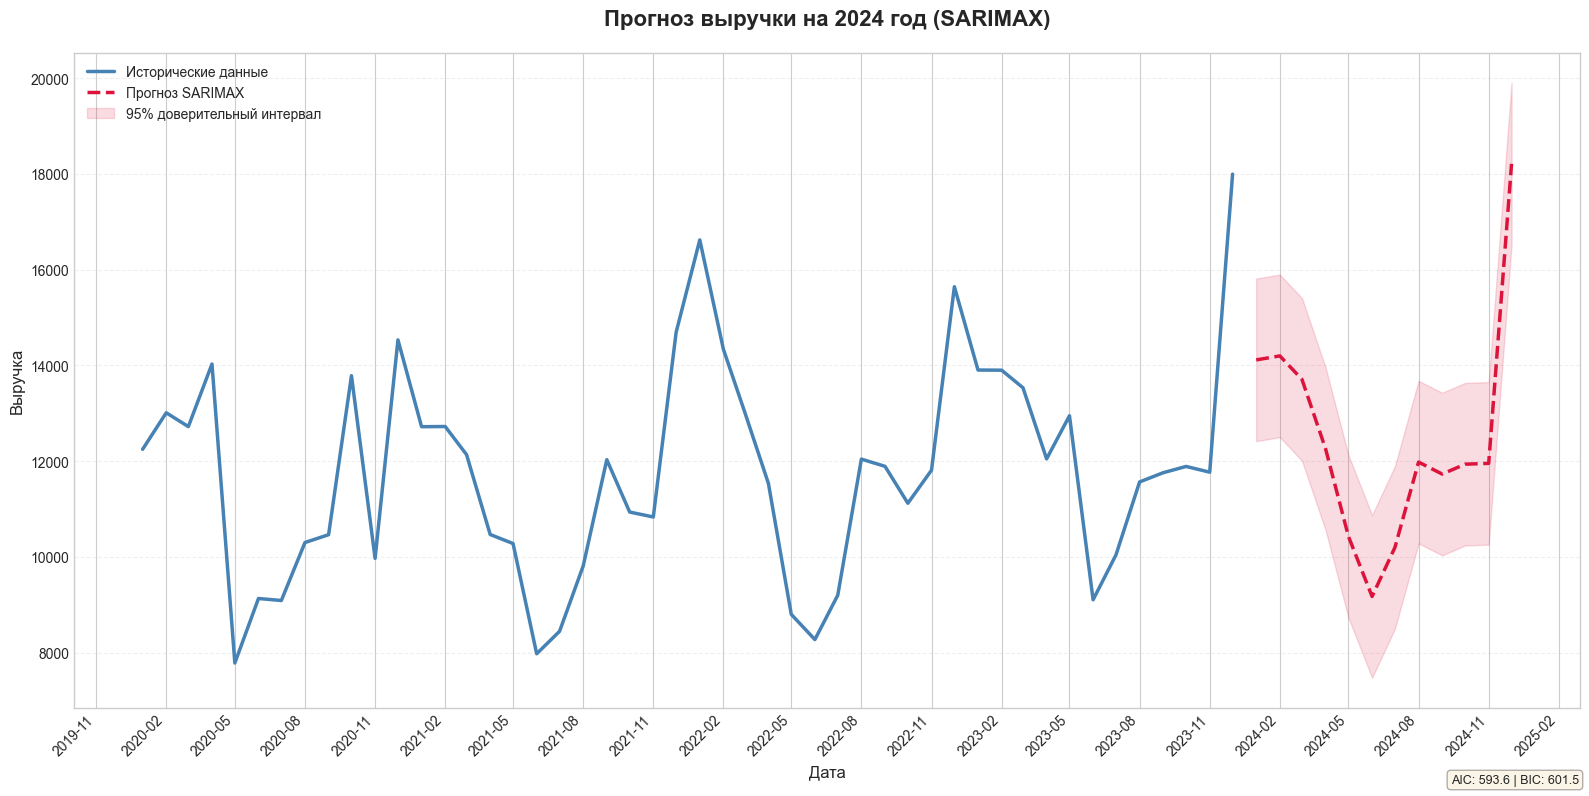

In [76]:
import matplotlib.dates as mdates

# Обучаю финальную модель на всех данных
exog_full = df[['Promotion', 'HolidayMonth']]

model_final = SARIMAX(
    df['SalesAmount'],
    exog=exog_full,
    order=(0, 0, 0),
    seasonal_order=(2, 1, 0, 12)
).fit(disp=False)

# Даты для прогноза (12 месяцев вперёд)
forecast_dates = pd.date_range(start='2024-01-01', periods=12, freq='MS')

# Экзогенные переменные для будущего периода (акции и праздники неизвестны, ставлю 0)
exog_future = pd.DataFrame({
    'Promotion': [0] * 12,
    'HolidayMonth': [0] * 12
}, index=forecast_dates)

# Получаю прогноз с доверительным интервалом
forecast_result = model_final.get_forecast(steps=12, exog=exog_future)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)

plt.figure(figsize=(16, 8))

sns.lineplot(x=df.index, y=df['SalesAmount'].values,
             label='Исторические данные', linewidth=2.5, color='steelblue')

sns.lineplot(x=forecast_dates, y=forecast_mean.values,
             label='Прогноз SARIMAX', linewidth=2.5, color='crimson', linestyle='--')

plt.fill_between(forecast_dates,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='crimson', alpha=0.15, label='95% доверительный интервал')

plt.title('Прогноз выручки на 2024 год (SARIMAX)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Выручка', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(plt.gca().xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')

stats_text = f'AIC: {model_final.aic:.1f} | BIC: {model_final.bic:.1f}'
plt.figtext(0.99, 0.01, stats_text, fontsize=9, ha='right', va='bottom',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()


Модель правильно уловила сезонный паттерн. В середине 2024 года она ожидает спад выручки, а к декабрю подъём, примерно так же как это происходило в предыдущие года

## 2.3 Оценка качества моделей

Метрики качества прогноза

MSE показывает среднеквадратичную ошибку, чем меньше тем точнее модель. R² показывает какую долю изменений в данных объясняет модель, значение близкое к 1 означает хорошее качество

In [77]:
from sklearn.metrics import mean_squared_error, r2_score

mse_arima   = mean_squared_error(test, forecast_arima)
r2_arima    = r2_score(test, forecast_arima)

mse_sarimax = mean_squared_error(test, forecast_sarimax)
r2_sarimax  = r2_score(test, forecast_sarimax)

print(f"{'Метрика':<10} {'ARIMA':>12} {'SARIMAX':>12}")
print(f"{'MSE':<10} {mse_arima:>12.2f} {mse_sarimax:>12.2f}")
print(f"{'R²':<10} {r2_arima:>12.4f} {r2_sarimax:>12.4f}")

Метрика           ARIMA      SARIMAX
MSE          4733414.56    658735.00
R²              -0.0235       0.8576


SARIMAX справилась намного лучше. R² = 0.86, что означент хорошее качество так как близко к 1.MSE снизился с 944405 до 658735. Значит SARIMAX(5,0,6)(2,1,0,12) точнее предсказывает реальные значения. У ARIMA R² вышел отрицательным, то есть она предсказывала хуже чем если бы я просто взяла среднее значение за всё время. ARIMA без сезонности работает плохо на моих данных

SARIMAX справилась значительно лучше ARIMA

Сравнение моделей по информационным критериям: AIC, BIC

In [78]:
import warnings
warnings.filterwarnings('ignore')

In [79]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Перебираю комбинации несезонных и сезонных параметров
nonseasonal_orders = [(0,0,0), (1,0,0), (0,0,1), (1,0,1), (5,0,6)]
seasonal_orders    = [(1,1,0,12), (2,1,0,12), (1,1,1,12), (0,1,1,12)]

aic_values = []
bic_values = []
params = []

for order in nonseasonal_orders:
    for s_order in seasonal_orders:
        model = SARIMAX(train, exog=exog_train, order=order, seasonal_order=s_order).fit(disp=False)
        aic_values.append(model.aic)
        bic_values.append(model.bic)
        params.append((order, s_order))
        print(f'SARIMAX{order}{s_order} — AIC: {model.aic:.2f}, BIC: {model.bic:.2f}')

best_aic = params[np.argmin(aic_values)]
best_bic = params[np.argmin(bic_values)]
print(f'\nЛучшая модель по AIC: SARIMAX{best_aic[0]}{best_aic[1]}')
print(f'Лучшая модель по BIC: SARIMAX{best_bic[0]}{best_bic[1]}')

SARIMAX(0, 0, 0)(1, 1, 0, 12) — AIC: 406.99, BIC: 411.70
SARIMAX(0, 0, 0)(2, 1, 0, 12) — AIC: 394.00, BIC: 399.89
SARIMAX(0, 0, 0)(1, 1, 1, 12) — AIC: 402.48, BIC: 408.37
SARIMAX(0, 0, 0)(0, 1, 1, 12) — AIC: 406.29, BIC: 411.00
SARIMAX(1, 0, 0)(1, 1, 0, 12) — AIC: 406.20, BIC: 412.09
SARIMAX(1, 0, 0)(2, 1, 0, 12) — AIC: 394.61, BIC: 401.67
SARIMAX(1, 0, 0)(1, 1, 1, 12) — AIC: 401.69, BIC: 408.76
SARIMAX(1, 0, 0)(0, 1, 1, 12) — AIC: 406.28, BIC: 412.17
SARIMAX(0, 0, 1)(1, 1, 0, 12) — AIC: 406.24, BIC: 412.13
SARIMAX(0, 0, 1)(2, 1, 0, 12) — AIC: 394.58, BIC: 401.65
SARIMAX(0, 0, 1)(1, 1, 1, 12) — AIC: 401.99, BIC: 409.06
SARIMAX(0, 0, 1)(0, 1, 1, 12) — AIC: 406.29, BIC: 412.18
SARIMAX(1, 0, 1)(1, 1, 0, 12) — AIC: 408.19, BIC: 415.26
SARIMAX(1, 0, 1)(2, 1, 0, 12) — AIC: 394.28, BIC: 402.53
SARIMAX(1, 0, 1)(1, 1, 1, 12) — AIC: 397.51, BIC: 405.75
SARIMAX(1, 0, 1)(0, 1, 1, 12) — AIC: 408.32, BIC: 415.39
SARIMAX(5, 0, 6)(1, 1, 0, 12) — AIC: 406.92, BIC: 424.59
SARIMAX(5, 0, 6)(2, 1, 0, 12) —

По обоим критериям лучшей оказалась модель SARIMAX(0,0,0)(2,1,0,12) с AIC = 394. Модели с большими несезонными параметрами вроде SARIMAX(5,0,6) показали худший AIC несмотря на то что визуально прогноз у них выглядел точнее. Скорее всего, просто во втором случае случилось переобучение

Анализ остатков моделей

Я проверяю остатки модели SARIMAX по трём критериям: нормальность распределения, отсутствие автокорреляции и однородность дисперсии

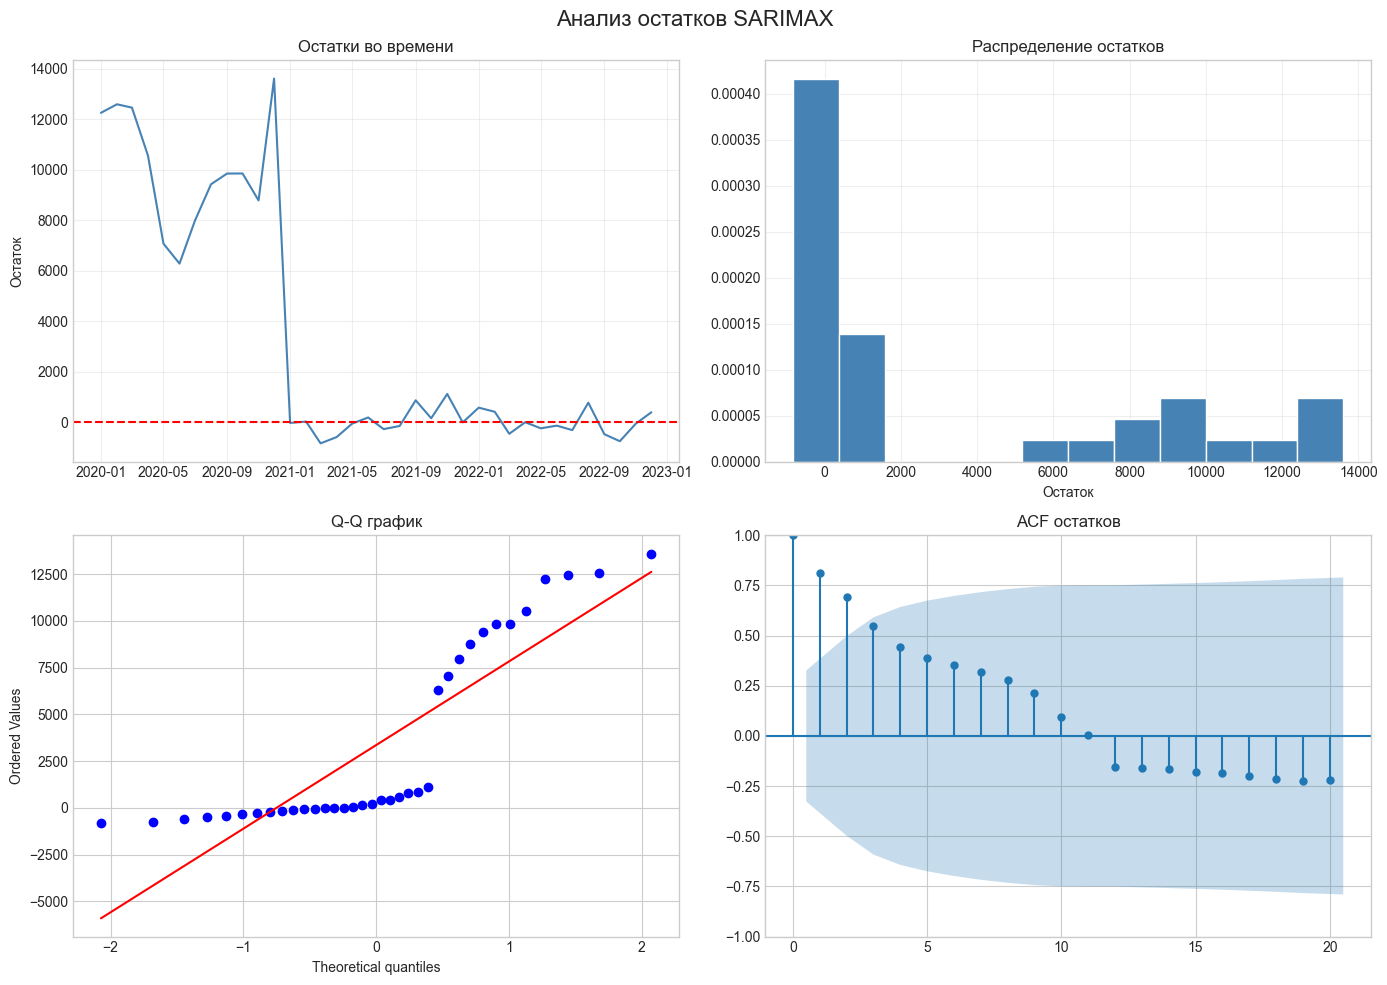

Тест Шапиро-Уилка (нормальность): p-value = 0.0000 -> не норм.
Тест Льюнга-Бокса (автокорреляция): p-value = 0.0000 -> есть автокорр.
Тест Бройша-Пагана (гомоскедастичн.): p-value = 0.0000 -> гетероскед.


In [82]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from scipy import stats

residuals = result_sarimax.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Анализ остатков SARIMAX', fontsize=16)

# Остатки во времени
axes[0, 0].plot(residuals, color='steelblue')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Остатки во времени')
axes[0, 0].set_ylabel('Остаток')
axes[0, 0].grid(True, alpha=0.3)

# Гистограмма
axes[0, 1].hist(residuals, bins=12, color='steelblue', edgecolor='white', density=True)
axes[0, 1].set_title('Распределение остатков')
axes[0, 1].set_xlabel('Остаток')
axes[0, 1].grid(True, alpha=0.3)

# QQ-plot
stats.probplot(residuals, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q график')

# ACF остатков
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=20, ax=axes[1, 1])
axes[1, 1].set_title('ACF остатков')

plt.tight_layout()
plt.show()

# Тесты
sw_stat, sw_pval = stats.shapiro(residuals)
print(f'Тест Шапиро-Уилка (нормальность): p-value = {sw_pval:.4f} -> {"норм." if sw_pval > 0.05 else "не норм."}')

lb = acorr_ljungbox(residuals, lags=[10], return_df=True)
lb_pval = lb['lb_pvalue'].values[0]
print(f'Тест Льюнга-Бокса (автокорреляция): p-value = {lb_pval:.4f} -> {"нет автокорр." if lb_pval > 0.05 else "есть автокорр."}')

bp_stat, bp_pval, _, _ = het_breuschpagan(residuals, sm.add_constant(range(len(residuals))))
print(f'Тест Бройша-Пагана (гомоскедастичн.): p-value = {bp_pval:.4f} -> {"гомоскед." if bp_pval > 0.05 else "гетероскед."}')
